<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/nlp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install Gensim
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.5 MB/s eta 0:00:00


In [ ]:
#Section 0 — Imports & setup
from gensim.models import Word2Vec
import numpy as np
import matplotlib.pyplot as plt
import nltk
from sklearn.decomposition import PCA
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
#Step 1 - Build the Corpus
raw_sentences = [
    # --- royalty + gender + "rules the kingdom" ---
    "the king rules the kingdom",
    "the queen rules the kingdom",
    "the king is a man",
    "the queen is a woman",
    "the prince is a young man",
    "the princess is a young woman",
    "the boy will become a king",
    "the girl will become a queen",
    "the man loves the woman",
    "the woman loves the man",
    # --- animals + "drinks/eats" ---
    "the cat drinks milk",
    "the kitten drinks milk",
    "the dog drinks water",
    "the puppy drinks water",
    "the cat eats fish",
    "the dog eats bread",
    "the kitten is a young cat",
    "the puppy is a young dog",
    "the lion is a big cat",
    "the cub is a young lion",
    # --- reinforce the patterns (repetition = learning) ---
    "the king and the queen rule together",
    "the man and the woman walk together",
    "the cat and the dog play together",
    "a young boy plays",
    "a young girl plays",
    "the king drinks water",
    "the queen drinks water",
    "the cat is an animal",
    "the dog is an animal",
    "the lion is an animal",
    "the man is a person",
    "the woman is a person",
    "the boy is a young person",
    "the girl is a young person",
    "the kitten plays with the puppy",
    "the prince loves the princess",
    "the princess loves the prince",
    "the king is a royal person",
    "the queen is a royal person",
    "milk and water are drinks",
]

# YOUR CODE: turn each sentence into a list of lowercase word tokens
# goal: tokenized = [['the','king','rules','the','kingdom'], [...], ...]
tokenized = [itr.lower().strip().split() for itr in raw_sentences if  itr not in stop_words]

print(f"{len(tokenized)} sentences")
print("example:", tokenized[0])

40 sentences
example: ['the', 'king', 'rules', 'the', 'kingdom']


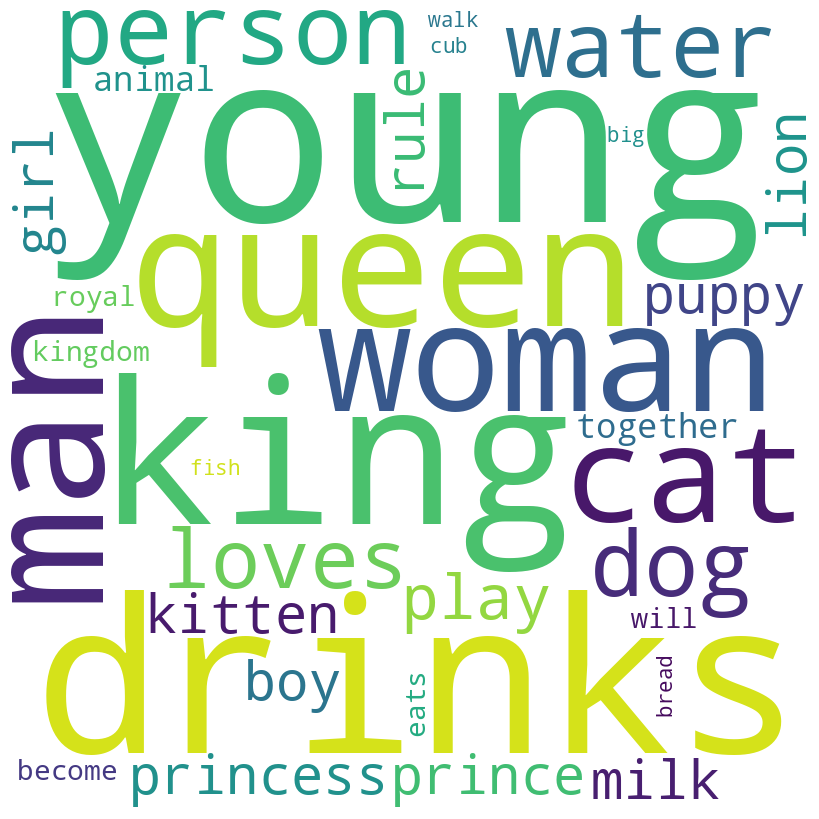

In [ ]:
#generate WordCloud of the given words
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#Convert the tokenized texts into one single line
all_words = ','.join( [item for sublist in tokenized for item in sublist] )
#print(all_words)

#Generate the WordCloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate(all_words)
#Plot the wordcloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()


In [ ]:
#Step 2 : Train the model
model = Word2Vec(
          sentences = tokenized,
          vector_size=100,
          window=5,
          sg=1,
          min_count=5

)
print('Training Done')

Training Done


In [ ]:
model.wv.index_to_key

['the',
 'a',
 'is',
 'young',
 'drinks',
 'person',
 'cat',
 'woman',
 'man',
 'queen',
 'king',
 'water',
 'dog']

In [ ]:
#Step 3 : Sanity check
#How many words are there in Vocabulary?

words = len(model.wv.index_to_key)
print(f'Number of words = {words}')
#Print any one words embedding
embedding = model.wv.get_vector('king')
print(f'Embedding of king = {embedding}')
#Shape of embedding
print(f'Shape of Embedding of king = {embedding.shape}')


Number of words = 13
Embedding of king = [ 7.0837475e-03 -1.5617693e-03  7.9554738e-03 -9.4916821e-03
 -8.0253016e-03 -6.6439495e-03 -3.9985846e-03  5.0023999e-03
 -3.8085666e-03 -8.3326772e-03  8.4186131e-03 -3.7469671e-03
  8.6055081e-03 -4.8995242e-03  3.9222199e-03  4.9154940e-03
  2.4033997e-03 -2.8188068e-03  2.8417155e-03 -8.2584796e-03
 -2.7657792e-03 -2.5948964e-03  7.2638728e-03 -3.4550775e-03
 -6.6100266e-03  4.3464205e-03 -4.7533077e-04 -3.5881859e-03
  6.8807038e-03  3.8803173e-03 -3.9029496e-03  7.6891331e-04
  9.1388701e-03  7.7470825e-03  6.3635586e-03  4.6704477e-03
  2.3897185e-03 -1.8516034e-03 -6.3801124e-03 -2.9456132e-04
 -1.5610415e-03 -5.6938699e-04 -6.2623010e-03  7.4324757e-03
 -6.5878378e-03 -7.2409594e-03 -2.7516056e-03 -1.5211474e-03
 -7.6393825e-03  7.0026889e-04 -5.3205597e-03 -1.2836469e-03
 -7.3704058e-03  1.9504568e-03  3.2652176e-03 -2.3485043e-05
 -5.4476387e-03 -1.7183997e-03  7.0900097e-03  3.7377710e-03
 -8.8840127e-03 -3.4138428e-03  2.3623602e-0

In [ ]:
#cosine similarity between 'king' and 'queen'
model.wv.similarity('king', 'queen')

np.float32(0.015184658)

In [ ]:
model.wv.similarity('king', 'man')

np.float32(0.026918534)

In [ ]:
#Step  4 — Similarity queries
# hint: model.wv.most_similar(word, topn=5)
model.wv.most_similar('king', topn=5)


[('dog', 0.12844055891036987),
 ('water', 0.1096259132027626),
 ('woman', 0.10917273908853531),
 ('the', 0.06306613236665726),
 ('cat', 0.05065350607037544)]

In [ ]:
#Step  5 — The analogy
# king +man -woman  ≈  ?
result = model.wv.most_similar(
    positive=[ 'king','man' ],     # YOUR CODE: which two words are ADDED?
    negative=['woman' ],       # YOUR CODE: which one is SUBTRACTED?
    topn=3,
)

In [ ]:
result

[('queen', 0.08682255446910858),
 ('person', 0.07846472412347794),
 ('dog', 0.07275551557540894)]